# Lymphoid Hematopoiesis — Visual Method Comparison

Qualitative and quantitative comparison of manifold-learning methods on the lymphoid hematopoiesis scATAC-seq dataset from Granja et al.\ (2019) \citep{granja2019lymphoid}, the only chromatin-accessibility (rather than transcript-abundance) benchmark in our bio suite.

The dataset captures **myeloid–lymphoid lineage specification** from hematopoietic stem cells (HSCs) through lymphoid-primed multipotent progenitors (LMPP) and common lymphoid progenitors (CLP) into Pre-B and plasmacytoid dendritic cells (pDC), with parallel myelo-erythroid branches via granulocyte-monocyte (GMP) and megakaryocyte-erythroid (MEP) progenitors. This is a richer trajectory topology than pancreas (single branch) or EB (linear time).

The standard representation for this dataset is **Latent Semantic Indexing (LSI)** rather than PCA — the standard scATAC-seq dimensionality reduction. Following Granja et al.\ and DTNE convention, the **first LSI component is dropped** as it correlates with sequencing depth (a known scATAC-seq artifact). We use LSI components 2-50 (49 dimensions) as the input representation.

## Imports

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parent.parent
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc

# Method classes
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from umap import UMAP
import phate
from entropath import EntroPath
from heatgeo.embedding import HeatGeo
from dtne import DTNE

from utils.bio_utils import (
    get_bio_methods, run_methods, compute_bio_metrics,
    plot_embedding_row, plot_embedding_grid,
    plot_pseudotime_panels, plot_pseudotime_boxplot,
    save_bio_artifacts, save_metrics_csv,
    geodesic_from_root, correlation_triple,
    BIO_PLOT_ORDER,
)
from entropath import EntroPath

import warnings
warnings.filterwarnings("ignore")
sc.settings.verbosity = 1

## Configuration

`K_NN = 15` matches pancreas / nestorowa / EB for cross-dataset consistency. The old MERW-PHATE notebook for this dataset used `k_aff=30`; we use 15 to align with the bio suite default. EntroPath uses landmarks here for the same reason as EB — landmarks improve DEMaP at any size in this kernel-based regime, not just for memory reasons.

In [2]:
SEED          = 42
K_NN          = 15           # consistent with pancreas/nestorowa/EB
N_LANDMARKS   = 2000

# Pseudotime root — HSC cell index 3047 (matches DTNE notebook)
ROOT_CELL_IDX = 3047

# Output paths
RESULTS_DIR = PROJECT_ROOT / "results" / "lymphoid"
FIGURES_DIR = PROJECT_ROOT / "figures" / "lymphoid"
DATA_DIR    = PROJECT_ROOT / "data" / "lymphoid"
for d in (RESULTS_DIR, FIGURES_DIR, DATA_DIR):
    d.mkdir(parents=True, exist_ok=True)

print(f"Random seed:  {SEED}")
print(f"k_nn:         {K_NN}")
print(f"n_landmarks:  {N_LANDMARKS}")
print(f"Root cell:    {ROOT_CELL_IDX}")
print(f"Results dir:  {RESULTS_DIR.relative_to(PROJECT_ROOT)}")
print(f"Figures dir:  {FIGURES_DIR.relative_to(PROJECT_ROOT)}")

Random seed:  42
k_nn:         15
n_landmarks:  2000
Root cell:    3047
Results dir:  results/lymphoid
Figures dir:  figures/lymphoid


## Load lymphoid dataset

Cache-first: looks for `lymphoid.h5ad` in `data/lymphoid/`. If absent, loads the source CSVs (`lymphoid_lsi.csv` and `lymphoid_celltype.csv`) and writes the cache.

In [3]:
CACHE_PATH = DATA_DIR / "lymphoid.h5ad"

if CACHE_PATH.exists():
    print(f"Loading cached data from {CACHE_PATH.name}")
    adata = sc.read_h5ad(CACHE_PATH)
else:
    lsi_csv      = DATA_DIR / "lymphoid_lsi.csv"
    celltype_csv = DATA_DIR / "lymphoid_celltype.csv"

    if not (lsi_csv.exists() and celltype_csv.exists()):
        raise FileNotFoundError(
            f"Place lymphoid_lsi.csv and lymphoid_celltype.csv in {DATA_DIR}. "
            "Available from the DTNE Google Drive: "
            "https://drive.google.com/drive/folders/1UFKBWFJ7BhzcABpa4DZXssthQuTGMfmU"
        )

    print(f"Loading from CSVs in {DATA_DIR.relative_to(PROJECT_ROOT)} ...")
    lsi_df      = pd.read_csv(lsi_csv, index_col=0)
    celltype_df = pd.read_csv(celltype_csv, index_col=0)

    # Drop the first LSI component (correlated with sequencing depth — known
    # scATAC-seq artifact). Use components 2-50 (49 dimensions).
    X_lsi      = lsi_df.iloc[:, 1:50].values.astype(np.float32)
    cell_types = celltype_df["x"].values

    adata = sc.AnnData(X=X_lsi)
    adata.obs_names = lsi_df.index.astype(str)
    adata.obs["cell_type"] = pd.Categorical(
        cell_types, categories=sorted(set(cell_types)),
    )
    adata.obsm["X_lsi"] = X_lsi

    print(f"Caching to {CACHE_PATH.name}")
    adata.write_h5ad(CACHE_PATH)

print(f"\nShape: {adata.shape}")
print(f"obs keys:  {list(adata.obs.columns)}")
print(f"obsm keys: {list(adata.obsm.keys())}")

Loading cached data from lymphoid.h5ad

Shape: (8221, 49)
obs keys:  ['cell_type']
obsm keys: ['X_lsi']


In [4]:
# Use LSI representation (scATAC-seq standard; first component already dropped)
if "X_lsi" in adata.obsm:
    X = adata.obsm["X_lsi"]
else:
    X = np.asarray(adata.X)
print(f"Using X (LSI components 2-50): shape {X.shape}")

# Labels and palette
labels       = adata.obs["cell_type"].values
label_codes  = adata.obs["cell_type"].cat.codes.values

categories   = list(adata.obs["cell_type"].cat.categories)
n_clusters   = len(categories)

# Bright categorical palette — cell types are discrete hematopoietic lineages
base_cmap = plt.get_cmap("tab10" if n_clusters <= 10 else "tab20")
palette_list = [base_cmap(i % base_cmap.N) for i in range(n_clusters)]
zip_types   = dict(zip(categories, palette_list))
cell_colors = [zip_types[l] for l in labels]

# Verify root cell is an HSC (the natural progenitor root)
root_label = labels[ROOT_CELL_IDX]
print(f"\nCell types ({n_clusters}):")
for cat in categories:
    n = int((labels == cat).sum())
    print(f"  {cat:>10s}: {n} cells")
print(f"\nRoot cell: idx={ROOT_CELL_IDX} (label={root_label})")

Using X (LSI components 2-50): shape (8221, 49)

Cell types (7):
         CLP: 651 cells
         GMP: 1842 cells
         HSC: 1010 cells
        LMPP: 1289 cells
         MDP: 1377 cells
       Pro-B: 1523 cells
         pDC: 529 cells

Root cell: idx=3047 (label=HSC)


## Run all methods

EntroPath is overridden to enable landmarks (matches the EB protocol; landmarks act as regularization in addition to providing speedup).

In [5]:
methods = {
    "PCA":       PCA(n_components=2),
    "t-SNE":     TSNE(perplexity=30, random_state=SEED),
    "UMAP":      UMAP(n_neighbors=30, min_dist=0.3, random_state=SEED),
    "PHATE":     phate.PHATE(n_jobs=-2, random_state=SEED, verbose=False),
    "HeatGeo":   HeatGeo(knn=5),
    "DTNE":      DTNE(k_neighbors=30),
    "EntroPath": EntroPath(k_neighbors=15, kernel="alpha_decay", mds_solver="smacof",
                           landmarks_method="kmeans", random_state=SEED, verbose=False),
}

print(f"Methods: {list(methods.keys())}\n")

embeddings, runtimes = run_methods(methods, X)

Methods: ['PCA', 't-SNE', 'UMAP', 'PHATE', 'HeatGeo', 'DTNE', 'EntroPath']

  PCA                done (   0.0s)
  t-SNE              done (  13.3s)
  UMAP               

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


done (  16.5s)
  PHATE                  SGD-MDS may not have converged: stress changed by 2.3% in final iterations. Consider increasing n_iter or adjusting learning_rate.
done (   4.7s)
  HeatGeo            Using s_gd2 for MDS. None
done (  65.6s)
  DTNE               done (   2.3s)
  EntroPath          done (  14.0s)  (t_power = 21)

=== Done — 7/7 methods succeeded ===


## Quantitative metrics

DEMaP via subsampling (DTNE protocol) is the primary metric. ARI/NMI on the seven hematopoietic cell types are interpretable here because the types correspond to relatively discrete differentiation stages, but a trajectory-preserving embedding may still score lower than a cluster-separating one — interpret with caution.

In [6]:
df_lymphoid = compute_bio_metrics(
    embeddings, X,
    label_codes=label_codes,
    n_clusters=n_clusters,
    runtimes=runtimes,
    plot_order=BIO_PLOT_ORDER,
    random_state=SEED,
)

print()
print(df_lymphoid.round(3).to_string())
print()
print("=== LaTeX ===")
print(df_lymphoid.round(3).to_latex(escape=False, float_format="%.3f"))

Computing bio metrics:
  DEMaP: n_subsample=2000, n_repeats=50, knn=50
  Trustworthiness/Continuity: k=15
  X_input == X_ref (single reference, shape (8221, 49))

  PCA                DEMaP = 0.615 ± 0.010, T = 0.757, C = 0.921
  t-SNE              DEMaP = 0.368 ± 0.010, T = 0.922, C = 0.973
  UMAP               DEMaP = 0.284 ± 0.012, T = 0.860, C = 0.979
  PHATE              DEMaP = 0.338 ± 0.012, T = 0.817, C = 0.958
  HeatGeo            DEMaP = 0.173 ± 0.007, T = 0.549, C = 0.684
  DTNE               DEMaP = 0.254 ± 0.014, T = 0.836, C = 0.972
  EntroPath          DEMaP = 0.493 ± 0.011, T = 0.812, C = 0.966

           DEMaP (mean)  DEMaP (std)    ARI    NMI  Trustworthiness  Continuity  Runtime (s)
Method                                                                                      
PCA               0.615        0.010 -0.000  0.039            0.757       0.921        0.001
t-SNE             0.368        0.010  0.455  0.609            0.922       0.973       13.252
UMAP     

## Plots

### Embedding row — primary figure

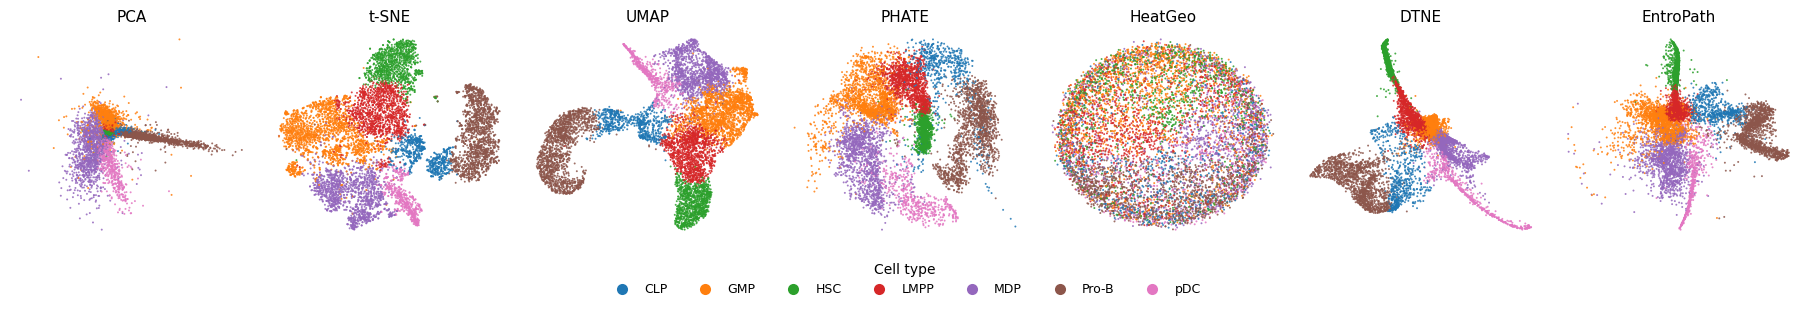

(<Figure size 1820x295 with 7 Axes>,
 array([<Axes: title={'center': 'PCA'}>, <Axes: title={'center': 't-SNE'}>,
        <Axes: title={'center': 'UMAP'}>,
        <Axes: title={'center': 'PHATE'}>,
        <Axes: title={'center': 'HeatGeo'}>,
        <Axes: title={'center': 'DTNE'}>,
        <Axes: title={'center': 'EntroPath'}>], dtype=object))

In [7]:
plot_embedding_row(
    embeddings, BIO_PLOT_ORDER, cell_colors, zip_types,
    runtimes=None,
    save_path=FIGURES_DIR / "lymphoid_row",
)

### Embedding grid (alternative layout)

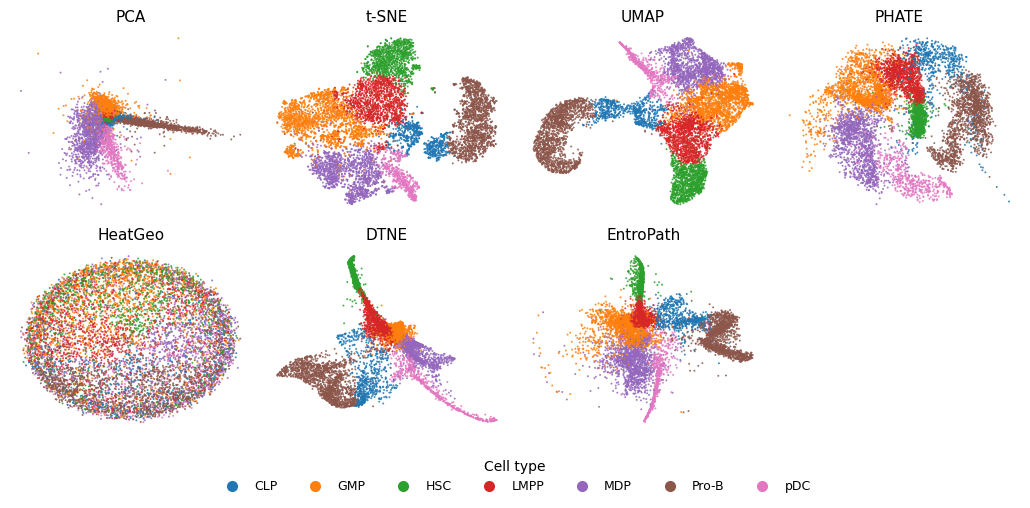

(<Figure size 1040x490 with 8 Axes>,
 array([<Axes: title={'center': 'PCA'}>, <Axes: title={'center': 't-SNE'}>,
        <Axes: title={'center': 'UMAP'}>,
        <Axes: title={'center': 'PHATE'}>,
        <Axes: title={'center': 'HeatGeo'}>,
        <Axes: title={'center': 'DTNE'}>,
        <Axes: title={'center': 'EntroPath'}>, <Axes: >], dtype=object))

In [8]:
plot_embedding_grid(
    embeddings, BIO_PLOT_ORDER, cell_colors, zip_types,
    runtimes=None,
    save_path=FIGURES_DIR / "lymphoid_grid",
)

## Save artifacts

In [9]:
artifact_path = save_bio_artifacts(
    embeddings, runtimes, labels, label_codes, zip_types,
    X_shape=X.shape,
    config={
        "seed":      SEED,
        "k_nn":      K_NN,
        "root_cell": ROOT_CELL_IDX,
    },
    results_dir=RESULTS_DIR,
    basename="lymphoid",
)
metrics_path = save_metrics_csv(df_lymphoid, RESULTS_DIR, "lymphoid")

print(f"Embeddings saved to {artifact_path.relative_to(PROJECT_ROOT)}")
print(f"Metrics saved to    {metrics_path.relative_to(PROJECT_ROOT)}")

Embeddings saved to results/lymphoid/lymphoid_embeddings.pkl
Metrics saved to    results/lymphoid/lymphoid_metrics.csv


## EntroPath downstream analysis

Root cell is index 3047 (an HSC, matching the old MERW-PHATE notebook). The boxplot below stratifies pseudotime by cell type — a well-ordered embedding shows HSC at lowest pseudotime and terminal lineages (Pre-B, pDC, MEP-derived) at highest.

Root cell 3047: type = HSC


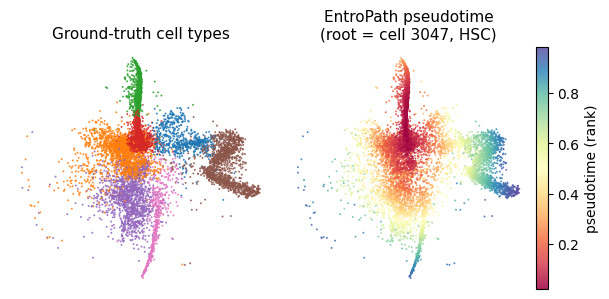


Pseudotime range: [0.021, 0.982]


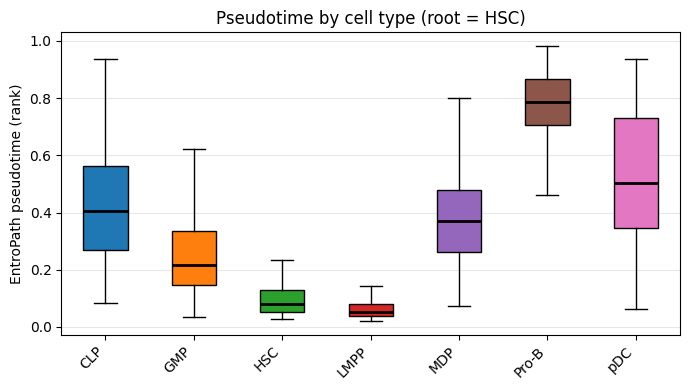

In [10]:
RUN_ENTROPATH_DOWNSTREAM = True

if RUN_ENTROPATH_DOWNSTREAM and "EntroPath" in embeddings:
    pseudotime = plot_pseudotime_panels(
        methods["EntroPath"], "EntroPath",
        embeddings["EntroPath"], ROOT_CELL_IDX,
        labels, cell_colors, zip_types,
        save_path=FIGURES_DIR / "lymphoid_entropath_pseudotime",
    )
    if pseudotime is not None:
        adata.obs["pseudotime_entropath"] = pseudotime
        print(f"\nPseudotime range: [{pseudotime.min():.3f}, {pseudotime.max():.3f}]")
        plot_pseudotime_boxplot(
            pseudotime, labels,
            adata.obs["cell_type"].cat.categories,
            zip_types,
            method_name="EntroPath",
            root_label=labels[ROOT_CELL_IDX],
            save_path=FIGURES_DIR / "lymphoid_pseudotime_by_type",
        )
elif RUN_ENTROPATH_DOWNSTREAM:
    print("EntroPath embedding not available — skipping downstream.")
else:
    print("Pseudotime skipped (set RUN_ENTROPATH_DOWNSTREAM = True)")

Root cell 3047: type = HSC


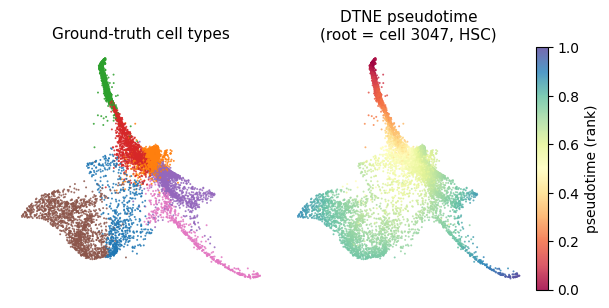


Pseudotime range: [0.000, 1.000]


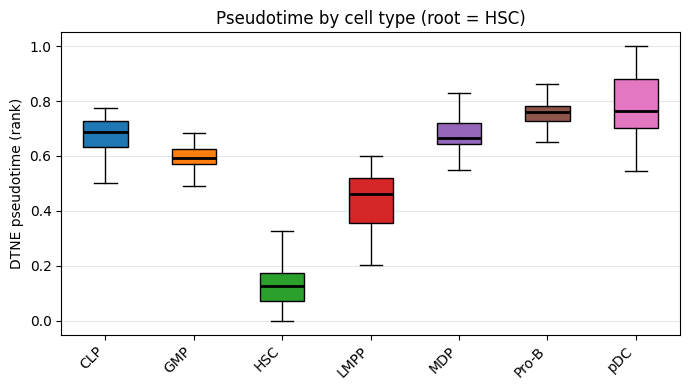

In [11]:
RUN_DTNE_DOWNSTREAM = True

if RUN_DTNE_DOWNSTREAM and "DTNE" in embeddings:
    pseudotime = plot_pseudotime_panels(
        methods["DTNE"], "DTNE",
        embeddings["DTNE"], ROOT_CELL_IDX,
        labels, cell_colors, zip_types,
        order_method="order_cells",
        save_path=FIGURES_DIR / "lymphoid_dtne_pseudotime",
    )
    if pseudotime is not None:
        adata.obs["pseudotime_dtne"] = pseudotime
        print(f"\nPseudotime range: [{pseudotime.min():.3f}, {pseudotime.max():.3f}]")
        plot_pseudotime_boxplot(
            pseudotime, labels,
            adata.obs["cell_type"].cat.categories,
            zip_types,
            method_name="DTNE",
            root_label=labels[ROOT_CELL_IDX],
            save_path=FIGURES_DIR / "dtne_lymphoid_pseudotime_by_type",
        )
elif RUN_DTNE_DOWNSTREAM:
    print("DTNE embedding not available — skipping downstream.")
else:
    print("Pseudotime skipped (set RUN_DTNE_DOWNSTREAM = True)")

In [12]:
ROOT = ROOT_CELL_IDX
geo = geodesic_from_root(X, ROOT, k_neighbors=20)
n_unreachable = int(np.isinf(geo).sum())
if n_unreachable:
    print(f"WARNING: {n_unreachable}/{len(geo)} cells unreachable from root at k=20 "
          f"(graph fragmented); correlations computed on reachable cells only.\n")

# Each method's pseudotime.
pseudotimes = {}
for name, key in [("EntroPath", "pseudotime_entropath"), ("DTNE", "pseudotime_dtne")]:
    if key in adata.obs:
        pseudotimes[name] = adata.obs[key].values
    else:
        print(f"[skip] {key} not in adata.obs — pseudotime not computed")

print(f"Geodesic-pseudotime correlation "
      f"(high-D input, k_neighbors=20, root cell {ROOT}, label={labels[ROOT]}):")
print(f"{'Method':<12s}  {'Pearson':>8s}  {'Spearman':>8s}  {'Kendall':>8s}")
print("-" * 44)
rows = []
for name, pt in pseudotimes.items():
    p, s, k = correlation_triple(geo, pt)
    print(f"{name:<12s}  {p:>8.3f}  {s:>8.3f}  {k:>8.3f}")
    rows.append({"Method": name, "Pearson": p, "Spearman": s, "Kendall": k})

df_geo = pd.DataFrame(rows).set_index("Method")
geo_path = RESULTS_DIR / "lymphoid_geodesic_pseudotime_corr.csv"
df_geo.to_csv(geo_path)
print(f"\nSaved to {geo_path.relative_to(PROJECT_ROOT)}")
print("\n=== LaTeX ===")
print(df_geo.round(3).to_latex(float_format="%.3f"))

Geodesic-pseudotime correlation (high-D input, k_neighbors=20, root cell 3047, label=HSC):
Method         Pearson  Spearman   Kendall
--------------------------------------------
EntroPath        0.426     0.645     0.461
DTNE             0.437     0.651     0.492

Saved to results/lymphoid/lymphoid_geodesic_pseudotime_corr.csv

=== LaTeX ===
\begin{tabular}{lrrr}
\toprule
 & Pearson & Spearman & Kendall \\
Method &  &  &  \\
\midrule
EntroPath & 0.426 & 0.645 & 0.461 \\
DTNE & 0.437 & 0.651 & 0.492 \\
\bottomrule
\end{tabular}



In [13]:
from scipy.stats import spearmanr

if "pseudotime_entropath" in adata.obs and "pseudotime_dtne" in adata.obs:
    pt_ep = adata.obs["pseudotime_entropath"].values
    pt_dt = adata.obs["pseudotime_dtne"].values
    mask = ~(np.isnan(pt_ep) | np.isnan(pt_dt))
    rho_sp, _ = spearmanr(pt_ep[mask], pt_dt[mask])
    print(f"\nPseudotime Spearman (EntroPath vs DTNE): {rho_sp:.3f}")


Pseudotime Spearman (EntroPath vs DTNE): 0.857


In [14]:
n_disconnected = np.sum(~np.isfinite(geo))
if n_disconnected > 0:
    print(f"WARNING: {n_disconnected} cells unreachable from root. "
          f"Increase k_neighbors.")